### This is a simple notebook to infer the parameters of a straight line model.

It accompanies Chapter 1 of the book.

Copyright: Viviana Acquaviva (2023)

License: [BSD-3-clause](https://opensource.org/license/bsd-3-clause/).  

modifications by Aaron Romanowsky

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

In [2]:
font = {'size'   : 16}
plt.rc('font', **font)
plt.rc('xtick', labelsize=14) 
plt.rc('ytick', labelsize=14) 
plt.rc('xtick.major', size=10, width=1.2)
plt.rc('ytick.major', size=10, width=1.2)
plt.rc('figure', figsize=[8,6])
#matplotlib.rcParams.update({'figure.autolayout': False})
#matplotlib.rcParams['figure.dpi'] = 300

In this notebook, we generate some data that follow a linear relationship with some noise, and we use a grid search to find the best fit model, with and without considering the uncertainties.

In [3]:
np.random.seed(16) #why are we fixing the seed?

x = np.arange(10) 

y = 2*x + 5 + np.random.randn(10) #generate some data with random gaussian scatter

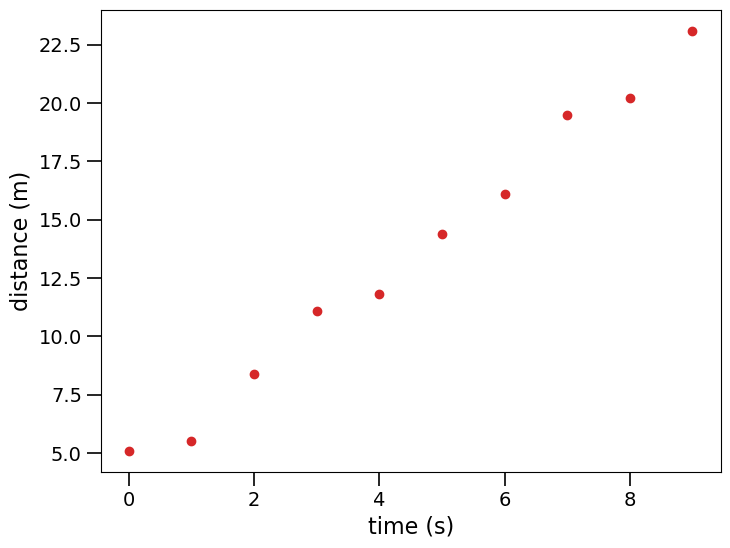

In [4]:
fig1 = plt.figure()
y = np.round(y,1) #match the book
plt.scatter(x,y, c = 'C3')
plt.xlabel('time (s)')
plt.ylabel('distance (m)');

Let's generate a grid of slopes and intercepts, after deciding a reasonable range by looking at the graph. 

In [5]:
slopes = np.linspace(1,3,101) # choosing 101 gives us nicer-looking numbers

intercepts = np.linspace(4,6,101)

In [6]:
slopes #just checking

array([1.  , 1.02, 1.04, 1.06, 1.08, 1.1 , 1.12, 1.14, 1.16, 1.18, 1.2 ,
       1.22, 1.24, 1.26, 1.28, 1.3 , 1.32, 1.34, 1.36, 1.38, 1.4 , 1.42,
       1.44, 1.46, 1.48, 1.5 , 1.52, 1.54, 1.56, 1.58, 1.6 , 1.62, 1.64,
       1.66, 1.68, 1.7 , 1.72, 1.74, 1.76, 1.78, 1.8 , 1.82, 1.84, 1.86,
       1.88, 1.9 , 1.92, 1.94, 1.96, 1.98, 2.  , 2.02, 2.04, 2.06, 2.08,
       2.1 , 2.12, 2.14, 2.16, 2.18, 2.2 , 2.22, 2.24, 2.26, 2.28, 2.3 ,
       2.32, 2.34, 2.36, 2.38, 2.4 , 2.42, 2.44, 2.46, 2.48, 2.5 , 2.52,
       2.54, 2.56, 2.58, 2.6 , 2.62, 2.64, 2.66, 2.68, 2.7 , 2.72, 2.74,
       2.76, 2.78, 2.8 , 2.82, 2.84, 2.86, 2.88, 2.9 , 2.92, 2.94, 2.96,
       2.98, 3.  ])

In [7]:
intercepts

array([4.  , 4.02, 4.04, 4.06, 4.08, 4.1 , 4.12, 4.14, 4.16, 4.18, 4.2 ,
       4.22, 4.24, 4.26, 4.28, 4.3 , 4.32, 4.34, 4.36, 4.38, 4.4 , 4.42,
       4.44, 4.46, 4.48, 4.5 , 4.52, 4.54, 4.56, 4.58, 4.6 , 4.62, 4.64,
       4.66, 4.68, 4.7 , 4.72, 4.74, 4.76, 4.78, 4.8 , 4.82, 4.84, 4.86,
       4.88, 4.9 , 4.92, 4.94, 4.96, 4.98, 5.  , 5.02, 5.04, 5.06, 5.08,
       5.1 , 5.12, 5.14, 5.16, 5.18, 5.2 , 5.22, 5.24, 5.26, 5.28, 5.3 ,
       5.32, 5.34, 5.36, 5.38, 5.4 , 5.42, 5.44, 5.46, 5.48, 5.5 , 5.52,
       5.54, 5.56, 5.58, 5.6 , 5.62, 5.64, 5.66, 5.68, 5.7 , 5.72, 5.74,
       5.76, 5.78, 5.8 , 5.82, 5.84, 5.86, 5.88, 5.9 , 5.92, 5.94, 5.96,
       5.98, 6.  ])

#### Note: these are already > 10000 models (curse of dimensionality!)

For convenience, we can define two functions. The first implements our model (a straight line) and the second one is the sum of squared errors that we can use to evaluate each slope, intercept pair (ignoring uncertainties for now).

In [8]:
def model(x,m,b):
    return m*x + b

def se(x,m,b,yobs):
    return np.sum((yobs - model(x,m,b))**2)

We can calculate the squared error for each value and save it in the "square_errs" array.

In [9]:
square_errs = np.zeros((101,101)) #Initialization

In [10]:
for i, m in enumerate(slopes):
    for j,b in enumerate(intercepts):
        square_errs[i,j] = se(x,m,b,y)

We can also do this with a one-liner by using list comprehension:

In [11]:
square_errs = np.array([[se(x,m,b,y) for b in intercepts] for m in slopes]) 

In [12]:
square_errs.shape #check that the array has been built properly

(101, 101)

In [13]:
square_errs

array([[346.34 , 344.336, 342.34 , ..., 187.972, 186.752, 185.54 ],
       [333.958, 331.99 , 330.03 , ..., 179.118, 177.934, 176.758],
       [321.804, 319.872, 317.948, ..., 170.492, 169.344, 168.204],
       ...,
       [216.588, 218.112, 219.644, ..., 403.964, 406.272, 408.588],
       [226.55 , 228.11 , 229.678, ..., 417.454, 419.798, 422.15 ],
       [236.74 , 238.336, 239.94 , ..., 431.172, 433.552, 435.94 ]],
      shape=(101, 101))

Note that this generates an array where the first index refers to slope and the second index refers to intercept.


#### Let's figure out which model is the best fit (lowest Squared Error).

In [14]:
np.argmin(square_errs) #index of min; however this corresponds to flattened array

np.int64(5269)

In [15]:
indices = np.unravel_index(square_errs.argmin(), square_errs.shape) #indices of minimum value as a (row, col) pair

print(indices)

(np.int64(52), np.int64(17))


We can now derive the slope and intercept for the best-fitting model.

In [16]:
bestm, bestb = slopes[indices[0]],intercepts[indices[1]]

In [17]:
bestm, bestb #How do they compare to the original ones?

(np.float64(2.04), np.float64(4.34))

Finally, we plot the best fit model against the data.

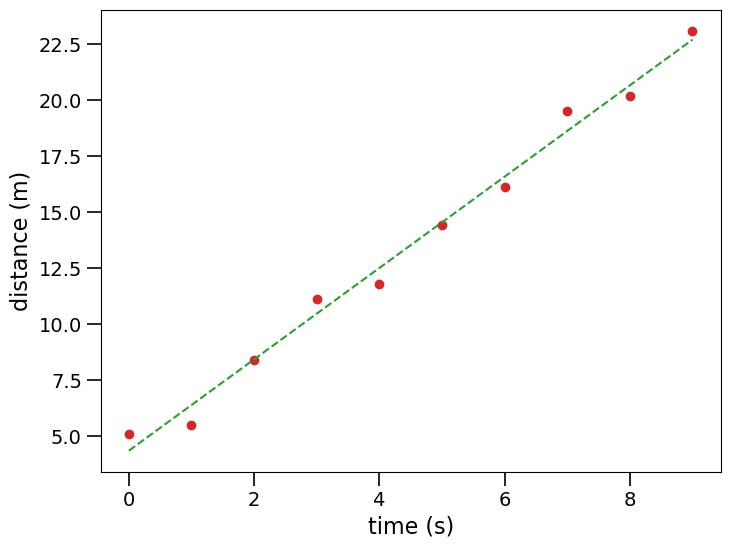

In [18]:
fig2 = plt.figure()
plt.scatter(x,y, c = 'C3')
plt.xlabel('time (s)')
plt.ylabel('distance (m)')
plt.plot(x, bestm * x + bestb, '--', c = 'C2'); 

What if there are uncertainties?

In [19]:
np.random.seed(10)

dy = np.random.randn(10)*np.sqrt(2) #these are the uncertainties; sign doesn't matter

In [20]:
dy

array([ 1.88314769,  1.01155723, -2.18552605, -0.01185655,  0.87870176,
       -1.01835477,  0.37549009,  0.1535108 ,  0.006069  , -0.24692199])

We want to consider the uncertainties by giving more weight to data points with a lower uncertainties. This can be achieved by modifying the squared error function with an inverse weight of the uncertainties. The error function becomes the chi squared.

In [21]:
def chi2(x,m,b,yobs,err):
    return np.sum(((yobs - model(x,m,b))**2/err**2))

We can now generate the array of the modified evaluation function, and find the indices of its minimum like we did above.

In [22]:
allchi2 = np.array([[chi2(x,m,b,y,dy) for b in intercepts] for m in slopes]) 

In [23]:
print(allchi2.argmin()) #index of min; however this corresponds to flattened array

indices = np.unravel_index(allchi2.argmin(), allchi2.shape) #indices of minimum value as a (row, col) pair

4223


In [24]:
#Derive the slope and intercept for best model

bestm_werr, bestb_werr = slopes[indices[0]],intercepts[indices[1]]

In [25]:
bestm_werr, bestb_werr

(np.float64(1.82), np.float64(5.640000000000001))

We can plot the data (with uncertainties) and the new best fit line.

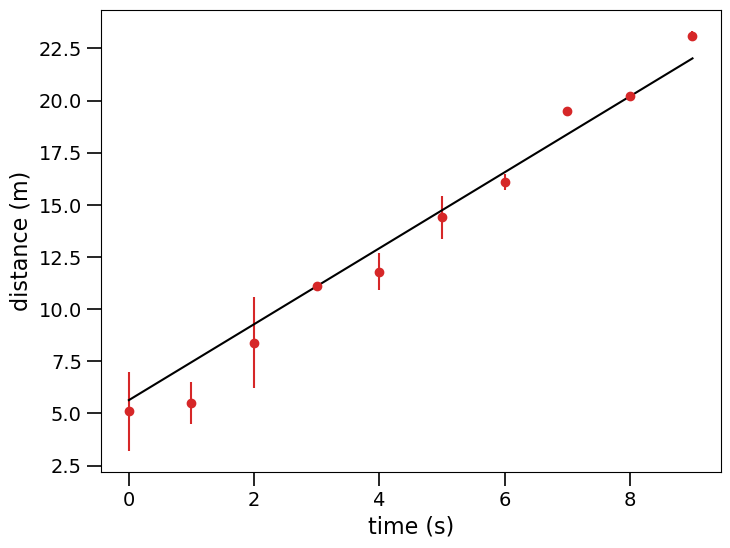

In [26]:
fig3 = plt.figure()
plt.errorbar(x,y, np.abs(dy), marker = 'o', markersize = 6, c = 'C3', linestyle = ' ')
plt.xlabel('time (s)')
plt.ylabel('distance (m)')
plt.plot(x, bestb_werr + bestm_werr * x, '-', c = 'black');

We can compare the two lines:

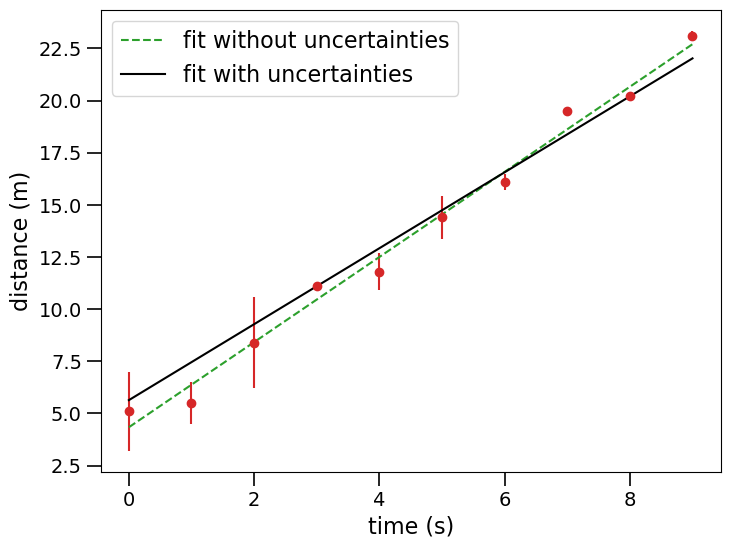

In [27]:
fig4 = plt.figure()

plt.errorbar(x,y, np.abs(dy), marker = 'o', markersize = 6, c = 'C3', linestyle = ' ')

plt.plot(x, bestb + bestm * x, '--', c = 'C2', label = 'fit without uncertainties')

plt.plot(x, bestb_werr + bestm_werr * x, '-', c = 'black', label = 'fit with uncertainties')

plt.xlabel('time (s)')

plt.ylabel('distance (m)')

plt.legend();

#plt.savefig('StraightLine_fig4.png')

Question: Does the change make sense?